# Análisis de Olist

Avanzamos con el notebook para analizar los datos del proyecto Olist.

## Estructura de Datos
Los datos se encuentran en la carpeta `Datos`, divididos en:
- `Tablas-Marketing`: Contiene información sobre leads y deals cerrados.
- `Tablas-Ordenes`: Contiene el núcleo de la información de e-commerce (clientes, órdenes, productos, etc.).

In [2]:
import pandas as pd
import os

# Definir rutas a los archivos
base_path = 'Datos'
marketing_path = os.path.join(base_path, 'Tablas-Marketing')
ordenes_path = os.path.join(base_path, 'Tablas-Ordenes')

# Cargar Tablas de Marketing
closed_deals = pd.read_csv(os.path.join(marketing_path, 'olist_closed_deals_dataset.csv'))
marketing_qualified_leads = pd.read_csv(os.path.join(marketing_path, 'olist_marketing_qualified_leads_dataset.csv'))

# Cargar Tablas de Ordenes
# Esta vez, vamos a usar un nombre diferente en la carga de tabla de datos.
customers = pd.read_csv(os.path.join(ordenes_path, 'olist_customers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(ordenes_path, 'olist_geolocation_dataset.csv'))
order_items = pd.read_csv(os.path.join(ordenes_path, 'olist_order_items_dataset.csv'))
order_payments = pd.read_csv(os.path.join(ordenes_path, 'olist_order_payments_dataset.csv'))
order_reviews = pd.read_csv(os.path.join(ordenes_path, 'olist_order_reviews_dataset.csv'))
orders = pd.read_csv(os.path.join(ordenes_path, 'olist_orders_dataset.csv'))
products = pd.read_csv(os.path.join(ordenes_path, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(ordenes_path, 'olist_sellers_dataset.csv'))
product_category_translation = pd.read_csv(os.path.join(ordenes_path, 'product_category_name_translation.csv'))

# Verificar la carga mostrando las dimensiones de cada DataFrame
datasets = {
    'Closed Deals': closed_deals,
    'Marketing Qualified Leads': marketing_qualified_leads,
    'Customers': customers,
    'Geolocation': geolocation,
    'Order Items': order_items,
    'Order Payments': order_payments,
    'Order Reviews': order_reviews,
    'Orders': orders,
    'Products': products,
    'Sellers': sellers,
    'Category Translation': product_category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Closed Deals: (842, 14)
Marketing Qualified Leads: (8000, 4)
Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


# Análisis Exploratorio

Vamos a hacer un análisis exploratorio muy basico respondiendo a algunas preguntas muy simples en este primer momento.

### Producto más vendido

In [3]:
order_items['product_id'].value_counts().head(1)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
Name: count, dtype: int64

### Vendedor que vendió más

In [4]:
order_items['seller_id'].value_counts().head(1)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
Name: count, dtype: int64

### Con qué medio pagan más en general en Brasil

In [5]:
order_payments['payment_type'].value_counts().head(1)

payment_type
credit_card    76795
Name: count, dtype: int64

El medio de pago predilecto es la "tarjeta de credito"

### Cuál es la cantidad más frecuente de cuotas que pagan en un pedido

In [6]:
order_payments['payment_installments'].value_counts().head(1)

payment_installments
1    52546
Name: count, dtype: int64

1 cuota es la cantidad mas frecuente de cuotas en la que suelen pagar los pedidos.

## Analisis Exploratorio de Datos profundo:
Hagamos ahora un analisis exploratorio de datos mas profundo y detallado para estudiar el comportamiento mas general de los datos y no simplemente preguntas sueltas, en la medida de lo posible tratare de plantear preguntas que intenten ser relevantes.


### 1. Cantidad de Sellers por Estado
Este gráfico muestra la distribución geográfica de los vendedores en Brasil, utilizando las abreviaturas de los estados.

C:\Users\locu\AppData\Local\Temp\ipykernel_38172\4047952794.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')


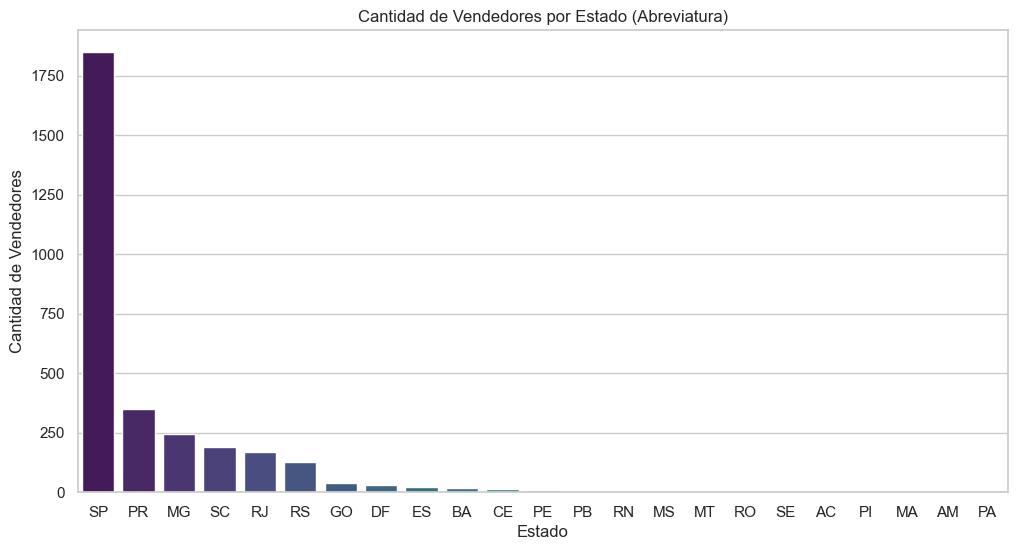

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
state_order = sellers['seller_state'].value_counts().index
sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')
plt.title('Cantidad de Vendedores por Estado (Abreviatura)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Vendedores')
plt.show()

El estado por mucho que mas vendedores tiene es Sao Paulo por mucho, seria interesante preguntar porque ¿Es la zona mas rica?.Para apreciar bien como los valores de los estados con menor cantidad de vendedores vamos a hacer el mismo grafico pero en con escala logaritmica en el eje Y.

### 1.2. Cantidad de Sellers por Estado (Escala Logarítmica)


C:\Users\locu\AppData\Local\Temp\ipykernel_38172\1482405418.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')


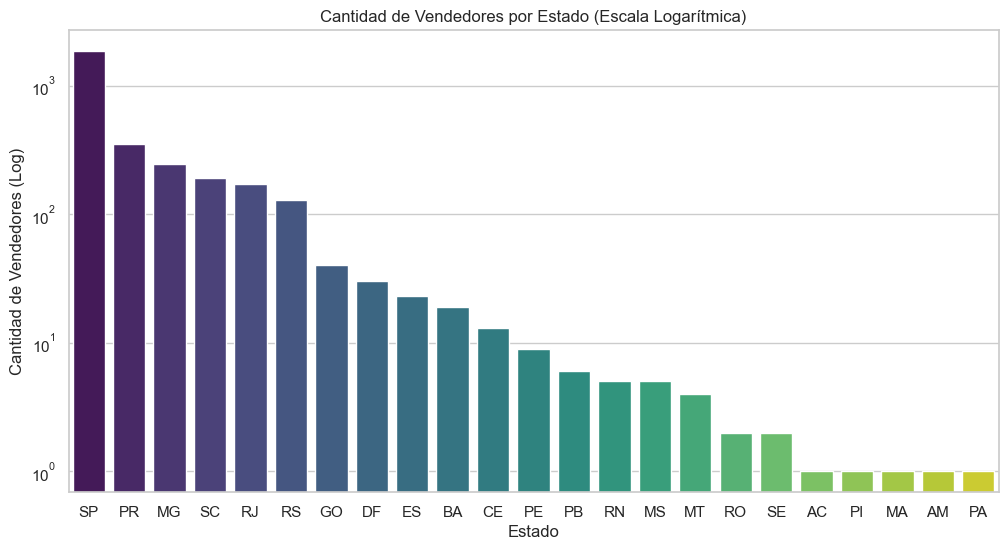

In [8]:
plt.figure(figsize=(12, 6))
state_order = sellers['seller_state'].value_counts().index
ax = sns.countplot(data=sellers, x='seller_state', order=state_order, palette='viridis')
ax.set_yscale("log")
plt.title('Cantidad de Vendedores por Estado (Escala Logarítmica)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Vendedores (Log)')
plt.show()

### 2. Cantidad de Compradores por Estado
Visualización de la distribución de clientes por estado.

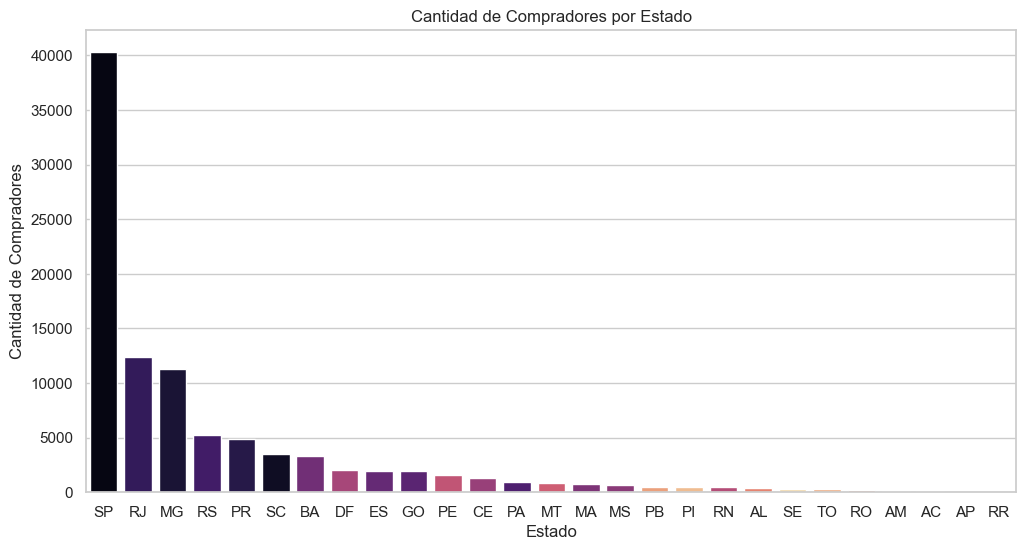

In [9]:
plt.figure(figsize=(12, 6))
customer_unique = customers.drop_duplicates('customer_unique_id')
customer_state_order = customer_unique['customer_state'].value_counts().index
sns.countplot(data=customer_unique, x='customer_state', order=customer_state_order, hue='customer_state', palette='magma', legend=False)
plt.title('Cantidad de Compradores por Estado')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Compradores')
plt.show()

El estado con mas compradores nuevamente es Sao Paulo, pero luego difieren en el orden de los estados mas vendedores, nuevamente voy aplicar escala logaritmica para poder apreciar la cantidad de compradores de los estados con menor cantidad

## 2.2  Cantidad de compradores por Estado (Escala Logarítmica)

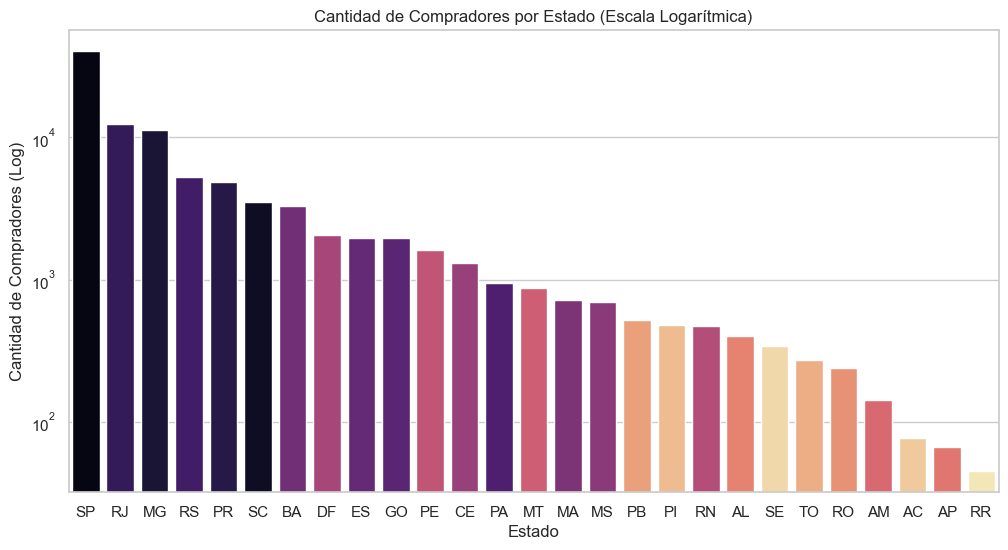

In [10]:
# Gráfico de cantidad de compradores por estado en escala logarítmica (como subitem de la sección 2)
plt.figure(figsize=(12, 6))
customer_unique = customers.drop_duplicates('customer_unique_id')
customer_state_order = customer_unique['customer_state'].value_counts().index
ax = sns.countplot(data=customer_unique, x='customer_state', order=customer_state_order, hue='customer_state', palette='magma', legend=False)
ax.set_yscale('log')
plt.title('Cantidad de Compradores por Estado (Escala Logarítmica)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Compradores (Log)')
plt.show()

### 3. Proporción de Compradores por Vendedor por Estado
Este gráfico representa cuántos compradores hay por cada vendedor en cada estado, permitiendo identificar niveles de competencia o demanda relativa.

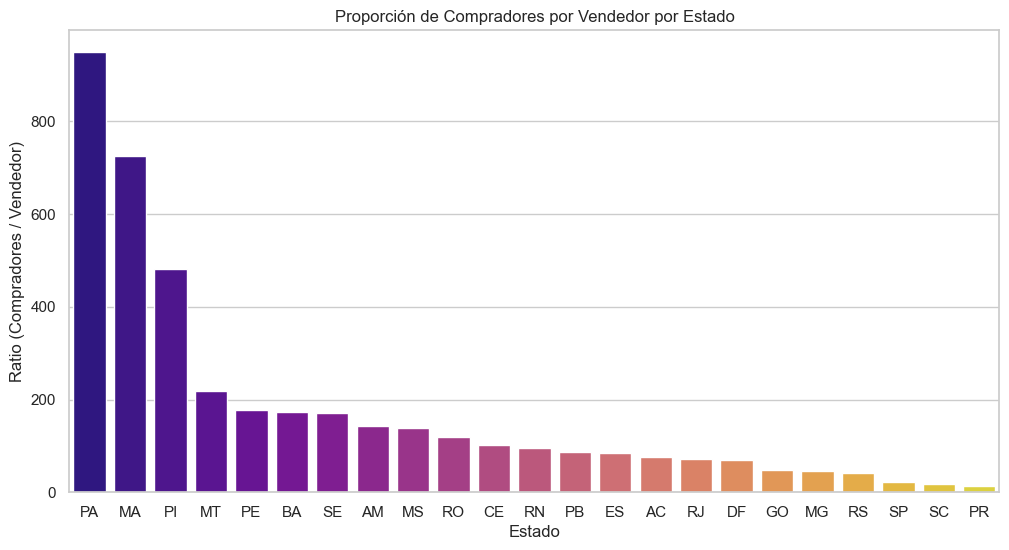

In [11]:
sellers_counts = sellers['seller_state'].value_counts()
customers_counts = customers.drop_duplicates('customer_unique_id')['customer_state'].value_counts()
df_counts = pd.DataFrame({'sellers': sellers_counts, 'customers': customers_counts}).fillna(0)
df_counts['ratio'] = df_counts['customers'] / df_counts['sellers']
# Filtramos estados sin vendedores para evitar divisiones por cero/infinito
df_counts = df_counts[df_counts['sellers'] > 0].sort_values('ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=df_counts.index, y=df_counts['ratio'], hue=df_counts.index, palette='plasma', legend=False)
plt.title('Proporción de Compradores por Vendedor por Estado')
plt.xlabel('Estado')
plt.ylabel('Ratio (Compradores / Vendedor)')
plt.show()



Es curioso que en el ratio compradores/vendedores la jerarquia casi que se invierte, los paises que tenian pocos vendedores y compradores aparecen primero, y los estados como Sau paulo quedan casi ultimo.Por lo que en el caso de "Para" (PA) se muestra que tiene casi 1000 veces mas compradores que vendedores. una buena pregunta seria ¿Las compras que hacen los habitantes de esa region, son locales ?.Podria indicar una buena opcion de negocio, faltaria comprar esto en funcion de los habitantes y la calidad de los productos que comercializan los vendedores asi como la que compran los compradores.Veamos el data frame para analizarlo mejor

In [12]:
display(df_counts)

,sellers,customers,ratio
PA,1.0,949,949.000000
MA,1.0,725,725.000000
PI,1.0,482,482.000000
MT,4.0,875,218.750000
PE,9.0,1604,178.222222
BA,19.0,3276,172.421053
SE,2.0,341,170.500000
AM,1.0,143,143.000000
MS,5.0,693,138.600000
RO,2.0,239,119.500000


Podemos observar que hay muchos estados con 1 solo seller, los podriamos considerar outliers en este caso y eliminarlos cuando hagamos alguna cuenta que involucre a los sellers.

### 4. Análisis de Montos de Pagos y ECDF
Distribución de montos y Función de Distribución Acumulada Empírica (ECDF) con media y desviaciones estándar.

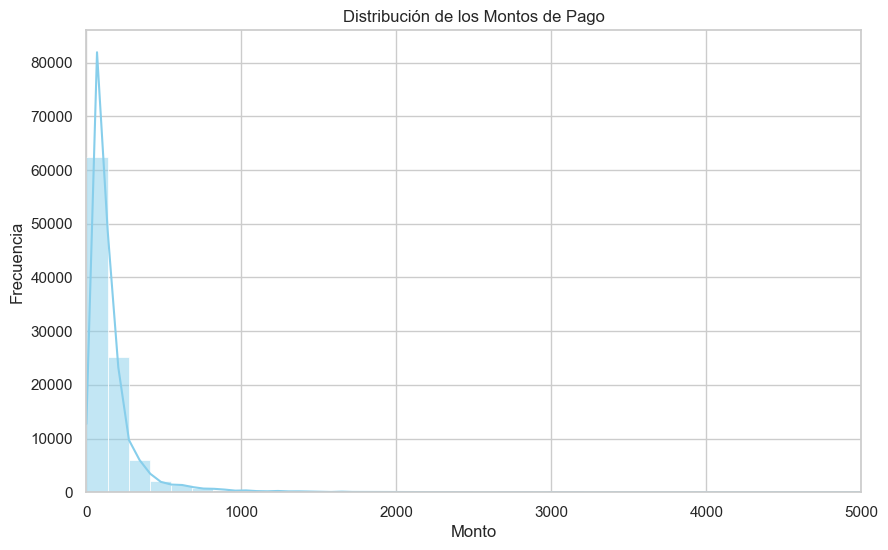

In [13]:
# Histograma
plt.figure(figsize=(10, 6))
order_payments_total = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
sns.histplot(order_payments_total['payment_value'], bins=100, kde=True, color='skyblue')
plt.title('Distribución de los Montos de Pago')
plt.xlabel('Monto')
plt.ylabel('Frecuencia')
plt.xlim(0, 5000)
plt.show()


Podemso ver que la mayor parte de los datos se acumulan enntre aproximadamente los precios menores a 250 reales, hagamos una "Función de Distribución Acumulativa Empírica" (ECDF) para ver mas claro esta distribucion.

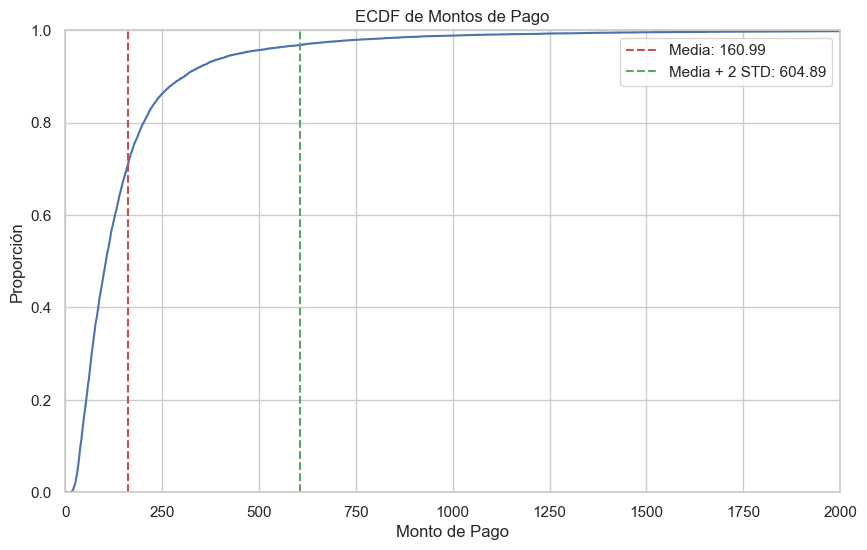

In [14]:
# ECDF
order_payments_total = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
mean_val = order_payments_total['payment_value'].mean()
std_val = order_payments_total['payment_value'].std()
upper_limit = mean_val + 2 * std_val

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=order_payments_total, x='payment_value')
plt.axvline(mean_val, color='r', linestyle='--', label=f'Media: {mean_val:.2f}')
plt.axvline(upper_limit, color='g', linestyle='--', label=f'Media + 2 STD: {upper_limit:.2f}')
plt.title('ECDF de Montos de Pago')
plt.xlabel('Monto de Pago')
plt.ylabel('Proporción')
plt.legend()
plt.xlim(0, 2000)
plt.show()

Podemos observar que mas de un 80% de los pagos se ubican en los monton menores a 250 reales.Tambien marcamos las lineas verticales roja siendo la mediana y la verde siendo la mediana mas dos desviaciones estandar, este sera el criterio para eliminar los valores atipicos ya que como se puede apreciar a simple vista, considerando este valor 605 reales mas del 90% de los datos se encuentran en este rango.

### 5. Métodos de Pago: Cantidad, Porcentaje y Boxplots
Análisis detallado de métodos de pago y sus valores.

C:\Users\locu\AppData\Local\Temp\ipykernel_38172\1947383450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')


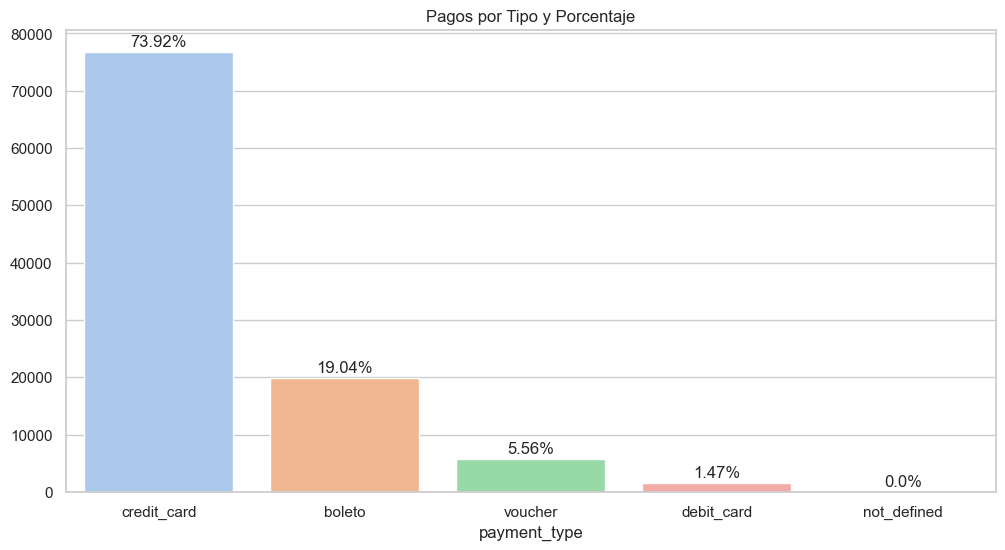

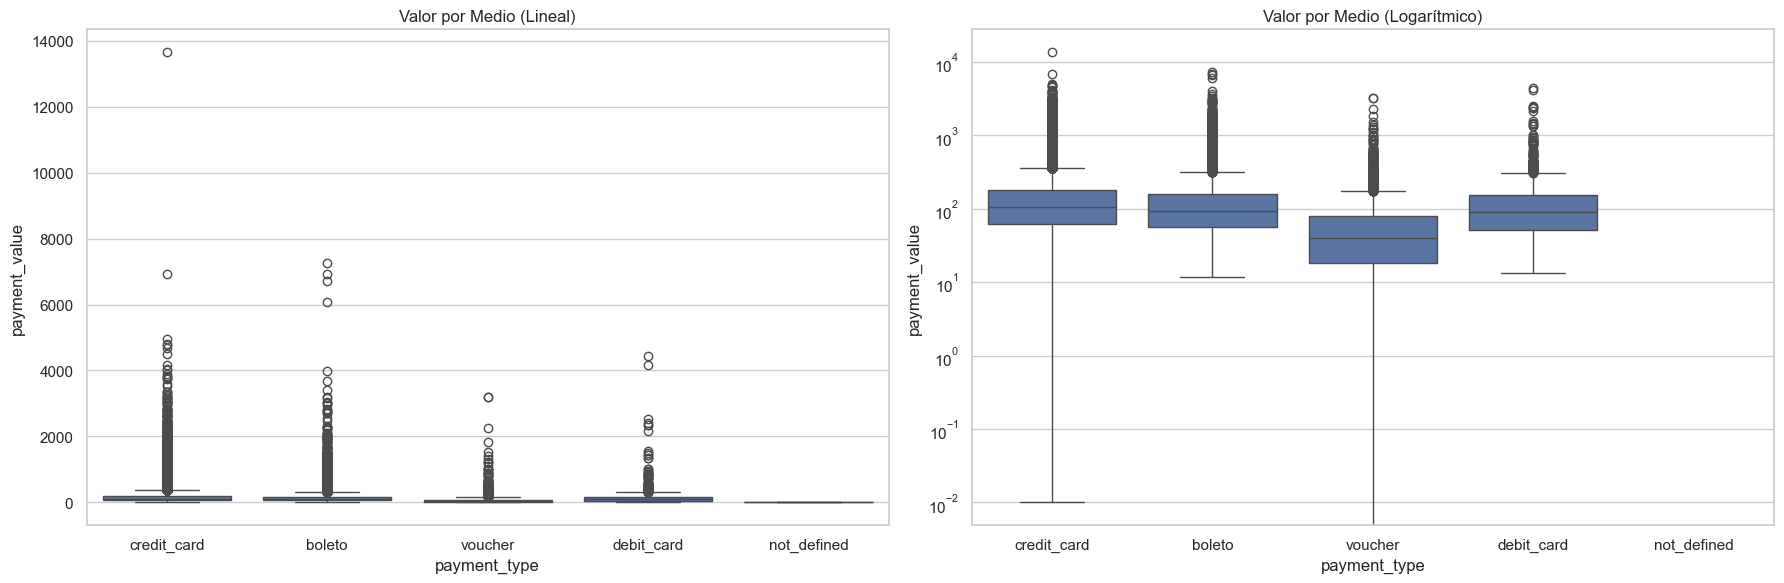

In [15]:

payment_counts = order_payments['payment_type'].value_counts()
payment_pct = (payment_counts / payment_counts.sum() * 100).round(2)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')
plt.title('Pagos por Tipo y Porcentaje')
for i, p in enumerate(ax.patches):
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 1000, f'{payment_pct.iloc[i]}%', ha="center")
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=order_payments, x='payment_type', y='payment_value', ax=ax1)
ax1.set_title('Valor por Medio (Lineal)')
sns.boxplot(data=order_payments, x='payment_type', y='payment_value', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Valor por Medio (Logarítmico)')
plt.tight_layout()
plt.show()

Cabe destacar una cosa, en nuestro codigo no agrupamos por "order_id", una misma fila "order_id" puede aparecer mas de una vez en una misma order si se pago con mas de un medio, por lo que esto no esta normalizada a la cantidad de ordenes.Dicho esto podemos observar que es pareja la comparacion entre los medios de pagos, se puede observar ligeramente que a pagos (o parte de pagos) mas altos se prefiere la tarjeta de credito.Para tener una idea de esto normalizado, vamos a comparar solamente los pagos que se hicieron de una sola vez

### 5.1 Valor de pago por tipo (Solo 1 cuota)
Filtramos los datos para incluir solo aquellos pedidos pagados en una sola cuota.

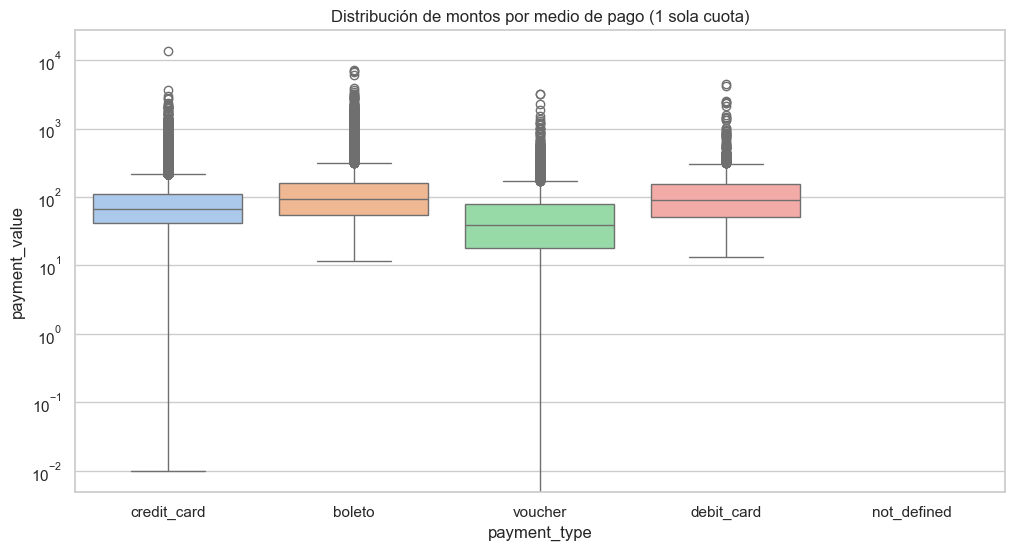

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=order_payments[order_payments['payment_installments'] == 1], x='payment_type', y='payment_value', hue='payment_type', palette='pastel', legend=False)
plt.title('Distribución de montos por medio de pago (1 sola cuota)')
plt.yscale('log')
plt.show()

La tendencia se mantiene relativamente estable, en este caso el "payment_value" fue el unico pago que se hizo por lo que no tenenemos contribuciones de mas de un metodo de pago a una misma orden.No vemos una diferencia sustancial entre el monto a pagar y el metodo de pago, ya que si bien la escala del eje Y es logaritmica las diferencias son chicas.Solo en el caso del voucher podemos apreciar que hay una diferencia mas marcado entre los otros medios de pago.Podria deberse esto a que un voucher es un credito de pago y no suelen ser tan grandes los montons ya que se suelen dar (de acuerdo a una investigacion por internet) como devolucion de un producto o como una promocion, inclusive se puede ver que el mayor de los outliners de los vouchers es el menor de todos.

### 5.2 Distribución de Cuotas por Pedido
Analizamos cuántas cuotas eligen los clientes para sus pagos, considerando el máximo de cuotas por pedido.

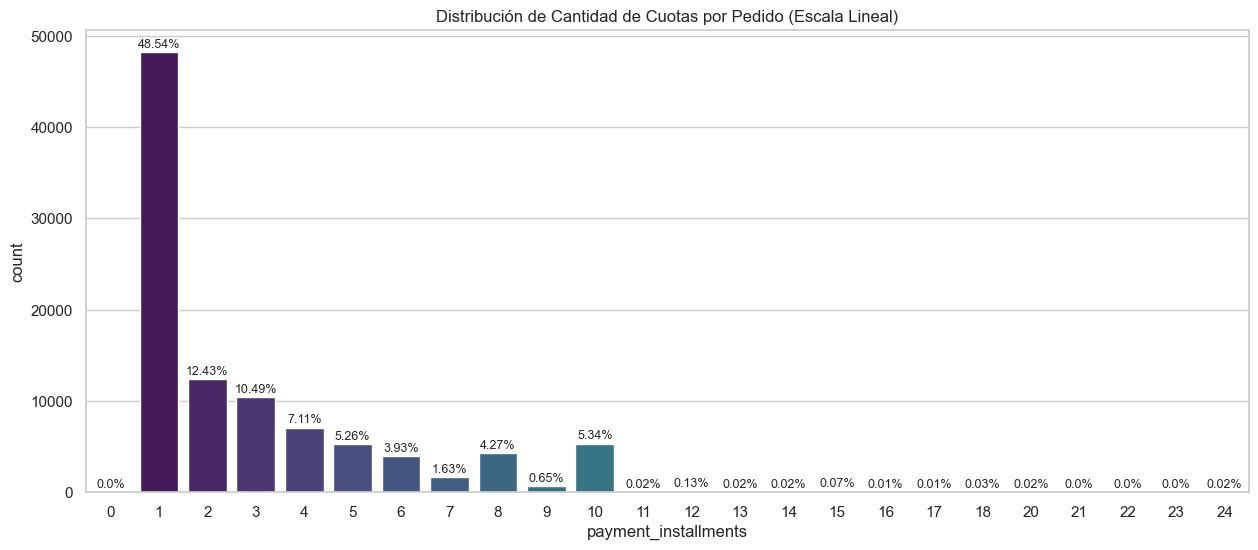

In [31]:
# Unimos por order_id y nos quedamos con el máximo de cuotas por orden
installments_per_order = order_payments.groupby('order_id')['payment_installments'].max().reset_index()

# Agrupamos por cantidad de cuotas y contamos
dist_installments = installments_per_order['payment_installments'].value_counts().sort_index().reset_index()
dist_installments.columns = ['payment_installments', 'count']

# Calculamos proporción
total_orders = dist_installments['count'].sum()
dist_installments['percentage'] = (dist_installments['count'] / total_orders * 100).round(2)

# Gráfico a escala lineal
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=dist_installments, x='payment_installments', y='count', hue='payment_installments', palette='viridis', legend=False)
plt.title('Distribución de Cantidad de Cuotas por Pedido (Escala Lineal)')
for i, p in enumerate(ax.patches):
    if not pd.isna(p.get_height()):
        ax.text(p.get_x() + p.get_width()/2., p.get_height() + (total_orders * 0.005), 
                f'{dist_installments["percentage"].iloc[i]}%', ha="center", fontsize=9)
plt.show()
'''
# Gráfico a escala logarítmica
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=dist_installments, x='payment_installments', y='count', hue='payment_installments', palette='viridis', legend=False)
plt.yscale('log')
plt.title('Distribución de Cantidad de Cuotas por Pedido (Escala Logarítmica)')
for i, p in enumerate(ax.patches):
    if not pd.isna(p.get_height()):
        ax.text(p.get_x() + p.get_width()/2., p.get_height(), 
                f'{dist_installments["percentage"].iloc[i]}%', ha="center", fontsize=9)
'''                
plt.show()

### 6. Relación entre Precio del Pedido y Valor del Flete
Dispersión entre el precio del producto y el costo de envío.

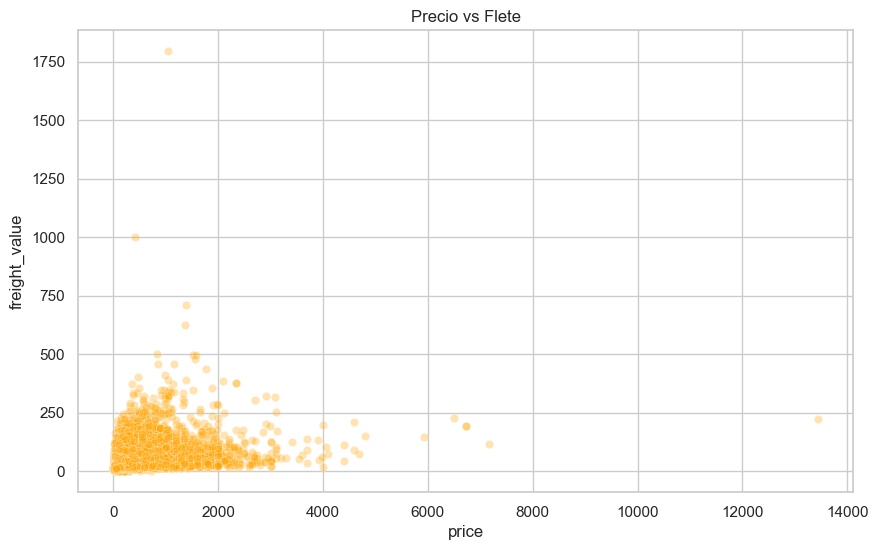

In [23]:
order_Aux = order_items[['order_id','price','freight_value']]
order_items_total = order_Aux.groupby('order_id')[['price', 'freight_value']].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=order_items_total, x='price', y='freight_value', alpha=0.3, color='orange')
plt.title('Precio vs Flete')
plt.show()

Pareciera ser una relacion de ruido de manual, no hay relacion entre el precio del valor del producto comprado y el valor del flete.No parece haber una relacion entre el precio de la orden y el flete, ¿La habra entre la cantidad de productos del pedido y el valor del flete? ¿Y entre el valor del flete y el lugar de procedencia entre el customer y el seller? ¿Y que pasa si considero todos estos features (valor del flete,residencia del customer,residencia del seller,cantidad de productos,valor del producto) al mismo tiempo ? ¿Cual seria la relacion que encontraria?

### 7. Boxplot del Flete por Estado
Variación del flete según ubicación del cliente.

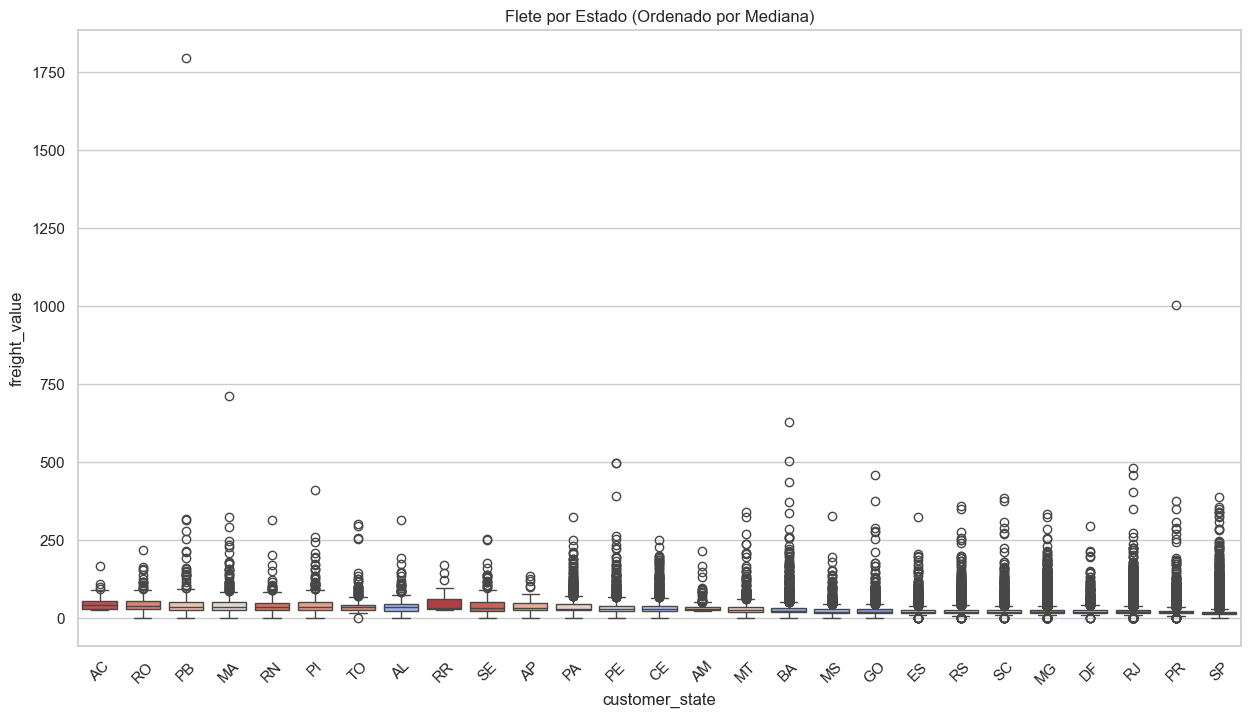

In [18]:
order_items_total = order_items.groupby('order_id')[['price', 'freight_value']].sum().reset_index()
df_freight = order_items_total.merge(orders, on='order_id').merge(customers, on='customer_id')
plt.figure(figsize=(15, 8))
order_states = df_freight.groupby('customer_state')['freight_value'].median().sort_values(ascending=False).index
sns.boxplot(data=df_freight, x='customer_state', y='freight_value', order=order_states, hue='customer_state', palette='coolwarm', legend=False)
plt.title('Flete por Estado (Ordenado por Mediana)')
plt.xticks(rotation=45)
plt.show()

Vamos a poner el eje Y en escala logaritmica asi se ve mejor.

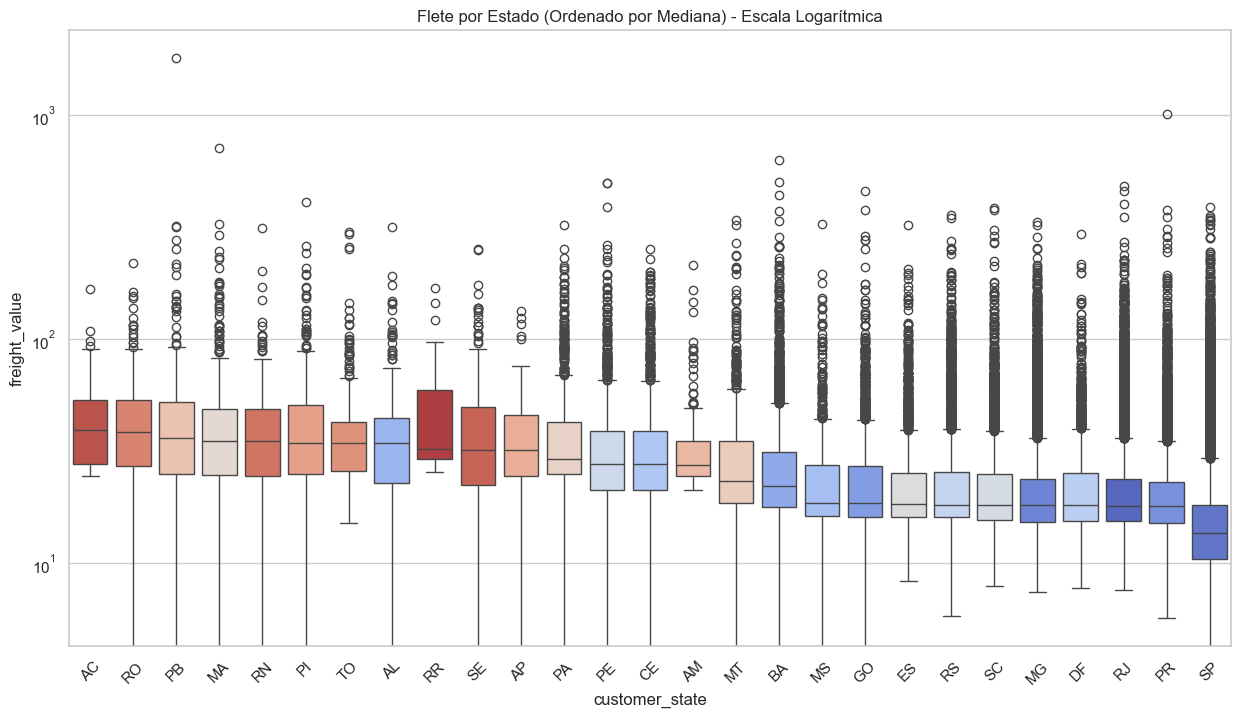

In [19]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_freight, x='customer_state', y='freight_value', order=order_states, hue='customer_state', palette='coolwarm', legend=False)
plt.yscale('log')
plt.title('Flete por Estado (Ordenado por Mediana) - Escala Logarítmica')
plt.xticks(rotation=45)
plt.show()

Claramente sao paulo es la mas barata en flete, ¿sera porque la mayoria de las ventas son del propio sau paulo? ¿sera porque tiene mejor infraestructura en general?.

### 8. Cantidad de Productos por Pedido
Visualizamos cuántos productos se incluyen típicamente en un solo pedido.

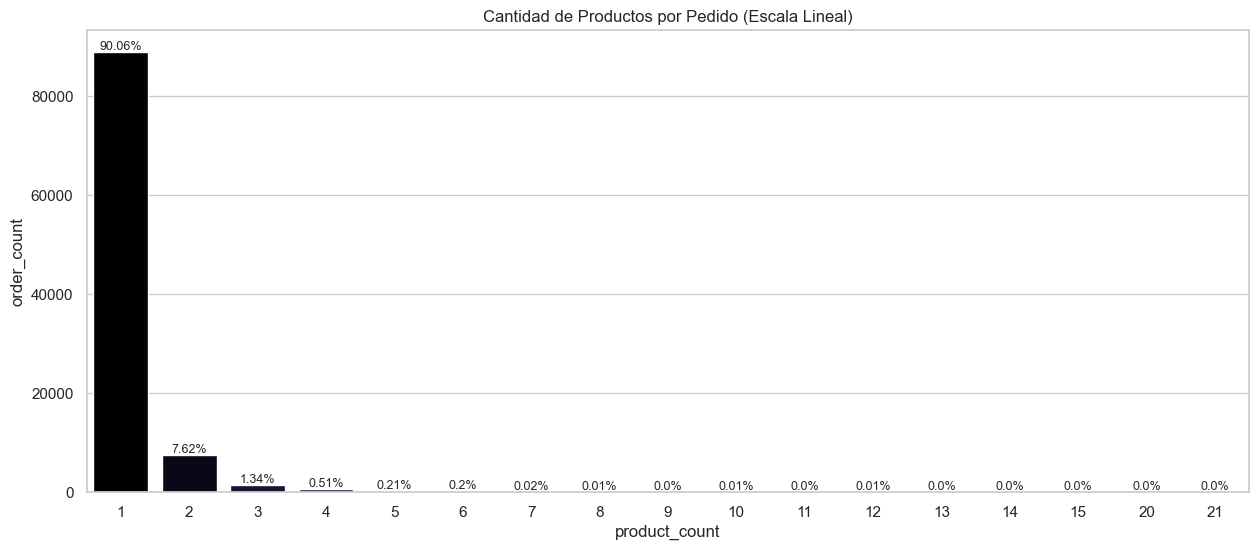

In [32]:
# Usamos order_items, nos quedamos con el máximo de order_item_id por order_id
items_per_order = order_items.groupby('order_id')['order_item_id'].max().reset_index()

# Contamos pedidos por cantidad de productos
dist_items = items_per_order['order_item_id'].value_counts().sort_index().reset_index()
dist_items.columns = ['product_count', 'order_count']

# Proporción
total_orders_items = dist_items['order_count'].sum()
dist_items['percentage'] = (dist_items['order_count'] / total_orders_items * 100).round(2)

# Gráfico a escala lineal
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=dist_items, x='product_count', y='order_count', hue='product_count', palette='magma', legend=False)
plt.title('Cantidad de Productos por Pedido (Escala Lineal)')
for i, p in enumerate(ax.patches):
    if not pd.isna(p.get_height()):
        ax.text(p.get_x() + p.get_width()/2., p.get_height() + (total_orders_items * 0.005), 
                f'{dist_items["percentage"].iloc[i]}%', ha="center", fontsize=9)
plt.show()

'''
# Gráfico a escala logarítmica
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=dist_items, x='product_count', y='order_count', hue='product_count', palette='magma', legend=False)
plt.yscale('log')
plt.title('Cantidad de Productos por Pedido (Escala Logarítmica)')
for i, p in enumerate(ax.patches):
    if not pd.isna(p.get_height()):
        ax.text(p.get_x() + p.get_width()/2., p.get_height(), 
                f'{dist_items["percentage"].iloc[i]}%', ha="center", fontsize=9)
'''                
plt.show()

### 9. Promedio de Calificaciones por Estado
Calculamos el promedio de las estrellas (review_score) de las compras realizadas en cada estado para evaluar la satisfacción del cliente por región.

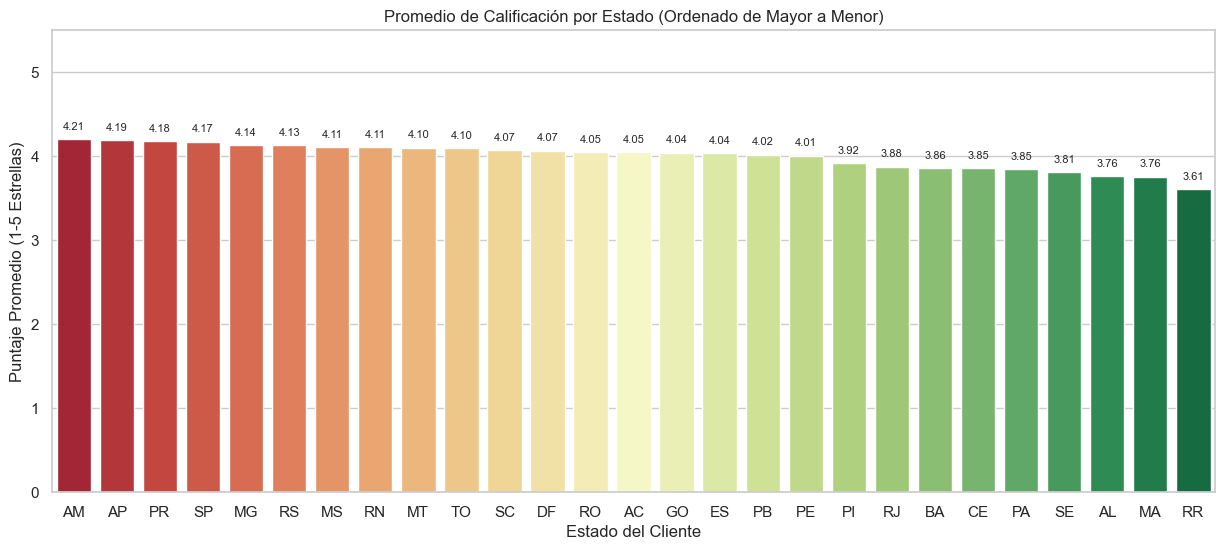

In [29]:
# Unimos reviews con órdenes para obtener el customer_id
df_reviews_orders = pd.merge(order_reviews[['order_id', 'review_score']], 
                             orders[['order_id', 'customer_id']], 
                             on='order_id')

# Unimos con customers para obtener el estado
df_reviews_state = pd.merge(df_reviews_orders, 
                            customers[['customer_id', 'customer_state']], 
                            on='customer_id')

# Agrupamos por orden primero para tener una calificación por compra (si hubiera varias reviews por orden)
# y luego agrupamos por estado para sacar el promedio
avg_reviews_per_order = df_reviews_state.groupby(['order_id', 'customer_state'])['review_score'].mean().reset_index()


state_reviews_avg = avg_reviews_per_order.groupby('customer_state')['review_score'].mean().sort_values(ascending=False).reset_index()

# Graficamos
plt.figure(figsize=(15, 6))
ax = sns.barplot(data=state_reviews_avg, x='customer_state', y='review_score', hue='customer_state', palette='RdYlGn', legend=False)
plt.title('Promedio de Calificación por Estado (Ordenado de Mayor a Menor)')
plt.ylabel('Puntaje Promedio (1-5 Estrellas)')
plt.xlabel('Estado del Cliente')
plt.ylim(0, 5.5)  # Damos espacio para las etiquetas

# Añadimos etiquetas de valor
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points', 
                    fontsize=8)

plt.show()
